# S&P 500 options: features that are model outputs

Every column `03_financial_features` wrote is a rule fixed before the data was seen - a window, a
difference, a rank within a date. This notebook writes four columns that are not: two of them are
what a *fitted* volatility model says the next day's volatility will be, and two are the gap
between that forecast and the volatility the option market is charging for the same day.

Two models produce the forecasts, and both are estimated once per training window and then held
fixed while they run forward:

1. **GJR-GARCH**, a variance recursion in which each day's variance is a weighted sum of
   yesterday's variance and yesterday's squared return, with an extra weight on the squared
   return when it was negative. Its five parameters are estimated by maximum likelihood.
2. **A stochastic-volatility model**, in which log-variance is itself a random walk that is never
   observed. Its single free parameter, the standard deviation of the random walk's steps, is
   estimated by Markov chain Monte Carlo; the unobserved daily volatility is then recovered by a
   particle filter.

**Learning objectives**. After working through this notebook you will be able to:

- Estimate a volatility model on one stretch of a price history and then run it forward over
  later dates without re-estimating it, so that no value it produces on those later dates was
  informed by them.
- Recover a daily estimate of a quantity a model never observes, by carrying a population of
  candidate values forward one day at a time and reweighting them against each day's return.
- Write the difference between a model's volatility forecast and the option market's implied
  volatility as a feature, and say what a positive value of it would mean.
- Check whether the same calendar day is given a different value by two passes of the same model
  estimated on different windows, and read off that comparison how often the models need
  re-estimating.
- Test whether a feature ranks a cross-section against the outcome that was actually traded,
  correcting the test for the fact that consecutive positions overlap in time.

**Reads**: the straddle quote panel and the underlying daily bars from the loaders;
`features/financial.parquet` from [`03_financial_features`](03_financial_features.ipynb), for the
calendar the walk-forward split is cut on and as the reference the new columns are compared
against in section F; and the primary label from [`02_labels`](02_labels.ipynb), read only by
section F.

**Writes**: `features/model_based.parquet`, one row per date, symbol and fold, and the small
JSON file recorded beside it.

**Book reference**: Chapter 9, Section 9.3 (Volatility Models)

**Prerequisites**: [`02_labels`](02_labels.ipynb),
[`03_financial_features`](03_financial_features.ipynb)

In [1]:
"""S&P 500 options: model-based features from GJR-GARCH and a particle-filtered SV model."""

import hashlib
import logging
import warnings
from datetime import date, timedelta

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import pymc as pm
import pytensor.tensor as pt
import yaml
from arch import arch_model
from ml4t.diagnostic.evaluation.stats import benjamini_hochberg_fdr
from ml4t.diagnostic.metrics import compute_ic_hac_stats, cross_sectional_ic_series

from case_studies.sp500_options._underlying_returns import reconcile_underlying_log_returns
from case_studies.utils.artifact_digest import read_digest, value_digest, write_artifact
from data import load_sp500_daily_bars, load_sp500_options_straddles
from utils.cv_splits import generate_cv_splits, load_evaluation_config
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds
from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")
logging.getLogger("pymc").setLevel(logging.ERROR)

## Configuration

Seven settings decide how much computation the stochastic-volatility half of the notebook does,
and each of them trades accuracy against time.

The Markov chain Monte Carlo step estimates one market-wide parameter, so it does not have to run
on every symbol: it runs on a pool of the ten symbols with the most quoted option dates inside the
training window, and the ten estimates are averaged. The pool size is what the step's cost is
linear in - ten fits per pass takes minutes, and every symbol would take days - and averaging over
ten stops any single company's volatility deciding the parameter. Each fit discards its first two
thousand draws while the sampler settles and keeps the next two thousand, on four chains started
from different points, because the only reliable evidence that a sampler has converged is that
separately started chains agree. The target acceptance rate makes the sampler take small, cautious
steps: this model's random-walk parameterization is badly enough conditioned that the sampler's
usual setting produces divergent transitions, which are steps it is known to have got wrong. The
retry settings are the second, longer attempt made for any symbol whose first fit fails the
convergence checks in section C.2.

The particle filter carries a thousand candidate values of the unobserved volatility forward
through each symbol's history. That count sets how finely the filter resolves the state: too few
and the estimate is noisy in a way that has nothing to do with the market.

The seed is threaded through every random draw. Section C.2 explains why it is combined with the
symbol rather than used directly.

In [2]:
SEED = 42
SV_POOL_SIZE = 10  # symbols the vol-of-vol parameter is estimated on, per fold
SV_N_PARTICLES = 1000  # candidate volatility states the particle filter carries
SV_DRAWS = 2000  # posterior draws kept per symbol
SV_TUNE = 2000  # draws discarded while the sampler adapts
SV_CHAINS = 4  # independently started chains
SV_TARGET_ACCEPT = 0.99  # step size target; higher means smaller, safer steps
SV_RETRY_DRAWS = 4000  # second attempt, for a symbol that fails the convergence checks
SV_RETRY_TUNE = 4000

In [3]:
CASE_DIR = get_case_study_dir("sp500_options")
FEATURES_DIR = CASE_DIR / "features"
LABELS_DIR = CASE_DIR / "labels"

STRATEGY_ID = "sp500_options"
set_global_seeds(SEED)

### What the models read

Two panels and one feature file. The straddle panel carries one end-of-session quote per symbol
per date for the at-the-money straddle nearest the target maturity, including the implied
volatility the two legs solve to; the daily bar panel carries the underlying's split- and
dividend-adjusted closes, which is what both models are fitted on. `financial.parquet` supplies
the calendar the walk-forward split is cut on - it has to be the same calendar the rest of the
case study uses - and in section F its columns are the reference the new ones are measured
against.

In [4]:
prices = load_sp500_options_straddles()
underlying = load_sp500_daily_bars(symbols=prices["symbol"].unique().sort().to_list())
features = pl.read_parquet(FEATURES_DIR / "financial.parquet")

print(f"Straddle quotes:  {prices.height:,} rows, {prices['symbol'].n_unique()} symbols")
print(f"Underlying bars:  {underlying.height:,} rows, {underlying['symbol'].n_unique()} symbols")
print(f"Feature calendar: {features['timestamp'].n_unique():,} sessions")

Straddle quotes:  361,010 rows, 627 symbols
Underlying bars:  631,926 rows, 627 symbols
Feature calendar: 1,238 sessions


### The walk-forward split

`generate_cv_splits` cuts the calendar into folds. Each fold has a training window the models are
estimated on and a validation window they are scored over, and consecutive folds are separated by
a gap wide enough that a position opened on the last training date has already closed before the
validation window starts. That gap is the label buffer declared in `setup.yaml`, set from how long
the straddle this case study sells runs before it expires. The holdout window is declared in the
same file and no fold reaches into it.

`hold_sessions` is how many NYSE sessions that expiry corresponds to. It appears twice below: it
annualizes a daily volatility, and it sets how far the standard errors in section F have to look
for the serial correlation that overlapping positions create.

In [5]:
_setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())
_eval = load_evaluation_config(STRATEGY_ID)
holdout_start = str(_eval["holdout_start"])
holdout_end = str(_eval["holdout_end"])
label_buffer = str(_setup["labels"]["buffer"])
LABEL_HORIZON_TRADING_DAYS = int(_setup["features"]["hold_sessions"])
PERIODS_PER_YEAR = int(_eval["periods_per_year"])
cv_folds = generate_cv_splits(
    features.select("timestamp"),
    case_study_id=STRATEGY_ID,
    label_buffer=label_buffer,
)
data_start = features["timestamp"].min()
# The pass fitted on everything before the holdout is written as one more fold, numbered after the
# last cross-validation fold. `utils/modeling.py::append_holdout_fold_if_needed` gives the holdout
# fold that same number, and `validate_temporal_fold_coverage` looks the artifact up by it.
HOLDOUT_FOLD = len(cv_folds)
holdout_train_end = (date.fromisoformat(holdout_start) - timedelta(days=1)).isoformat()

print(f"Label buffer between training and validation: {label_buffer}")
print(f"Holding period: {LABEL_HORIZON_TRADING_DAYS} NYSE sessions")
print(f"\nCross-validation folds: {len(cv_folds)}")
for fold in cv_folds:
    print(
        f"  Fold {fold['fold']}: train {fold['train_start'].date()}..{fold['train_end'].date()}, "
        f"validation {fold['val_start'].date()}..{fold['val_end'].date()}"
    )
print(
    f"  Fold {HOLDOUT_FOLD}: train {data_start}..{holdout_train_end}, "
    f"holdout {holdout_start}..{holdout_end}"
)

Label buffer between training and validation: 35D
Holding period: 21 NYSE sessions

Cross-validation folds: 2
  Fold 0: train 2018-01-05..2019-11-12, validation 2020-01-06..2020-11-10
  Fold 1: train 2017-02-02..2018-11-12, validation 2019-01-07..2020-01-03
  Fold 2: train 2017-02-02..2020-12-31, holdout 2021-01-01..2021-12-31


One consequence of writing values across the holdout is easy to miss. Every summary this notebook
prints or draws - a mean, a spread, a median - would otherwise be computed over those rows too,
and a number computed over the holdout is a number read off it. The models may write there; the
notebook may not look.

The line is drawn where a number stops describing the shape of a file and starts describing what
is inside it. How many rows a panel holds, how many symbols it names and what dates it spans are
shape; they are fixed by the loaders and the fold windows, and they are shown whole because the
rest of the notebook cannot be followed without them. Anything computed from the values - a mean,
a spread, a median, a count of how often a column is empty, a per-period breakdown - goes through
the filter defined here.

In [6]:
HOLDOUT_START = date.fromisoformat(holdout_start)


def before_holdout(frame: pl.DataFrame) -> pl.DataFrame:
    """Return the rows dated before the holdout begins."""
    return frame.filter(pl.col("timestamp") < HOLDOUT_START)

### The universe the models are fitted across

It is not the same size throughout. S&P 500 membership turns over, options are listed and
delisted, and a symbol only appears on a date when a straddle near the target maturity was quoted
on it. Year by year below: how many sessions the year holds, how many symbols were quoted at
least once in it, the median number quoted on a single day, and the thinnest single day in it.

Those last two are what the cross-sectional test in section F rests on - a rank correlation is
only as informative as the number of names it ranks, and the thinnest day is what the minimum
that test accepts has to clear. The panel continues through the holdout year; its coverage is not
shown, for the reason given just above.

In [7]:
coverage_by_year = (
    before_holdout(prices)
    .group_by(["timestamp", pl.col("timestamp").dt.year().alias("year")])
    .agg(pl.col("symbol").n_unique().alias("quoted"))
    .group_by("year")
    .agg(
        pl.len().alias("sessions"),
        pl.col("quoted").median().round(0).cast(pl.Int64).alias("median_quoted_per_day"),
        pl.col("quoted").min().alias("thinnest_day"),
    )
    .join(
        before_holdout(prices)
        .group_by(pl.col("timestamp").dt.year().alias("year"))
        .agg(pl.col("symbol").n_unique().alias("symbols_in_year")),
        on="year",
    )
    .select("year", "sessions", "symbols_in_year", "median_quoted_per_day", "thinnest_day")
    .sort("year")
)
coverage_by_year

year,sessions,symbols_in_year,median_quoted_per_day,thinnest_day
i32,u32,u32,i64,u32
2017,251,527,212,173
2018,251,525,249,72
2019,252,524,252,226
2020,253,517,226,44


## A. Why a fitted feature is different

A feature in `03_financial_features` is a function of past prices: a twenty-one-session realized
volatility on 3 March uses the returns of the twenty-one sessions ending 3 March, and nothing
else. Whatever else is in the file cannot reach it.

A feature here is a function of past prices *and* of parameters that were themselves estimated
from prices. The estimation window is therefore part of the feature's information set, and it is
an easy one to get wrong, because it is invisible in the value. A conditional volatility for
3 March computed from parameters fitted on 2017-2021 looks exactly like one computed from
parameters fitted on 2017-2019. The first has read four years of the future; the second has not.

The discipline that removes it is to **estimate once, then run forward without re-estimating**.
Parameters are fitted on a training window and held fixed while the variance recursion or the
particle filter walks through later dates one at a time. Re-fitting on a longer window and then
recomputing the whole series - the obvious thing to do, and what a plain call to a volatility
library does - would make every value in the series depend on every date in it.

## B. The fold contract

Below is what each pass fits on and what it produces, one row per pass. Read it left to right:
the dark bar is the window whose returns the parameters were estimated from, and the amber bar is
the window over which the values those parameters produce could not have been informed by the
dates they describe. No dark bar extends into its own amber bar, which is the property the whole
section exists to establish.

Values are also written for the dark span. A model training on a fold needs a volatility column
for its own training dates, and those values are legitimate for that purpose even though the
parameters that produced them were estimated from the same window - the model is not being scored
there. Only the amber span may be scored, which is why the two are drawn differently.

The last row is the pass whose parameters come from every date before the holdout and which then
runs forward through it. That is deliberate: a later stage has to be able to score a model over
the holdout, and it cannot do that if the volatility columns are undefined there. It is safe for
the same reason every other row is safe - nothing to the right of the red rule entered the fit.

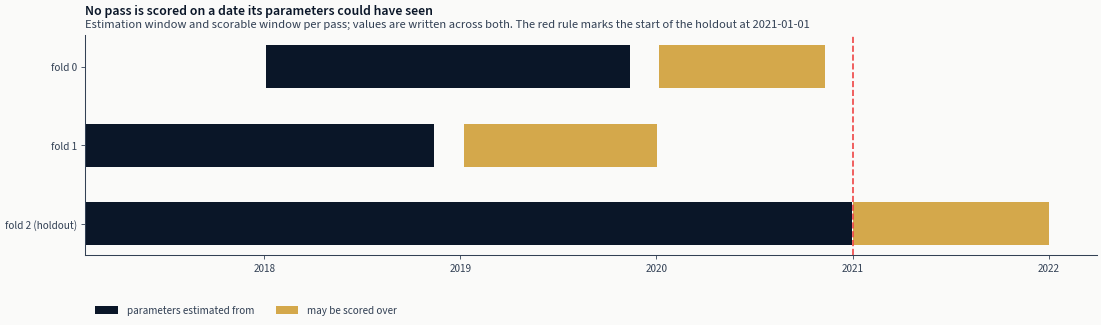

In [8]:
fig, ax = plt.subplots(figsize=(11, 3.2))
rows = [
    (
        f"fold {fold['fold']}",
        fold["train_start"],
        fold["train_end"],
        fold["val_start"],
        fold["val_end"],
    )
    for fold in cv_folds
]
rows.append(
    (f"fold {HOLDOUT_FOLD} (holdout)", data_start, holdout_train_end, holdout_start, holdout_end)
)
for row, (_label, tr_start, tr_end, ap_start, ap_end) in enumerate(rows):
    tr_start, tr_end = pd.Timestamp(tr_start), pd.Timestamp(tr_end)
    ap_start, ap_end = pd.Timestamp(ap_start), pd.Timestamp(ap_end)
    ax.barh(
        row,
        tr_end - tr_start,
        left=tr_start,
        height=0.55,
        color=COLORS["blue"],
        label="parameters estimated from" if row == 0 else None,
    )
    ax.barh(
        row,
        ap_end - ap_start,
        left=ap_start,
        height=0.55,
        color=COLORS["amber"],
        label="may be scored over" if row == 0 else None,
    )
ax.axvline(pd.Timestamp(holdout_start), color=COLORS["negative"], linestyle="--", linewidth=1.2)
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([r[0] for r in rows])
ax.invert_yaxis()
ax.legend(loc="lower left", bbox_to_anchor=(0, -0.32), ncol=2, frameon=False, fontsize=8)
add_message_title(
    ax,
    "No pass is scored on a date its parameters could have seen",
    subtitle=(
        "Estimation window and scorable window per pass; values are written across both. "
        f"The red rule marks the start of the holdout at {holdout_start}"
    ),
)
show_with_alt(
    fig,
    "Horizontal timeline with one row per pass, each row drawn as the window its parameters "
    "are estimated from followed by the window it may be scored over. Fold 0 estimates across "
    "2018 to late 2019 and is scorable through 2020; fold 1 starts earlier, estimating to late "
    "2018 and scorable through 2019 into 2020; the holdout pass estimates across everything up "
    "to 2021 and is scorable only after it. A dashed red vertical rule marks the start of the "
    f"holdout at {holdout_start}, and no pass's scorable window begins before its own "
    "estimation window ends.",
)

### The returns both models read

Both models are fitted on the underlying's daily log returns, scaled by a hundred so that a
typical day is a number near one rather than a small fraction - the optimizer and the sampler
both behave better on that scale, and the scaling is undone before anything is written.

A ticker is not a company. A symbol can be reassigned after a delisting, and a company can be
reorganized under the same symbol, so the loader assigns a **security identity** - the `sec_id`
column - that changes when the series behind the ticker changes. A return spanning such a change
is an artefact of the reassignment rather than a move anyone experienced, so those returns are
dropped, and every model below is fitted on one **(symbol, security identity)** pair at a time.
Nothing - a return, a set of fitted parameters, a filtered volatility state - crosses from one
such pair to another. For brevity the rest of the notebook calls one of these pairs a *segment*.

A segment needs at least a hundred returns before either model is worth fitting on it.

In [9]:
reconciled_returns = reconcile_underlying_log_returns(underlying)
identity_boundaries = reconciled_returns.filter(pl.col("identity_boundary"))

returns_df = (
    reconciled_returns.with_columns((pl.col("clean_log_return") * 100).alias("log_ret_pct"))
    .filter(pl.col("log_ret_pct").is_not_null())
    .select(["timestamp", "symbol", "sec_id", "log_ret_pct"])
)

print(f"Returns: {returns_df.height:,} rows, {returns_df['symbol'].n_unique()} symbols")
print(f"Returns spanning a security identity change, dropped: {identity_boundaries.height:,}")

Returns: 631,272 rows, 627 symbols
Returns spanning a security identity change, dropped: 15


In [10]:
segment_returns: dict[tuple[str, int], pd.Series] = {}
for segment in returns_df.partition_by(["symbol", "sec_id"], maintain_order=True):
    symbol = segment["symbol"].item(0)
    sec_id = int(segment["sec_id"].item(0))
    segment_pd = segment.sort("timestamp").to_pandas().set_index("timestamp")
    if len(segment_pd) >= 100:
        segment_returns[(symbol, sec_id)] = segment_pd["log_ret_pct"]

print(
    f"Segments with at least 100 returns: {len(segment_returns)} "
    f"across {len({key[0] for key in segment_returns})} symbols"
)

Segments with at least 100 returns: 620 across 609 symbols


## C. One section per model

### C.1 GJR-GARCH

GARCH models write today's variance as a weighted sum of yesterday's variance and yesterday's
squared return. The GJR variant (Glosten, Jagannathan and Runkle 1993) adds a third term that
fires only when yesterday's return was negative:

$$h_t = \omega + \alpha \varepsilon_{t-1}^2 + \gamma \varepsilon_{t-1}^2 \mathbf{1}[\varepsilon_{t-1} < 0] + \beta h_{t-1}$$

That extra term is there because a fall of a given size raises subsequent volatility more than a
rise of the same size does - the asymmetry equity index options are priced around, and the reason
a symmetric GARCH understates volatility exactly when a short-volatility position is losing.

Four parameters plus a constant mean are estimated by maximum likelihood on the training window.
The recursion is then run forward over the segment's whole history with those parameters held
fixed, one day at a time, each day reading only the previous day's variance and squared return.

The recursion is written out below rather than taken from the fitting library, and the reason is
worth stating because it is the kind of leak a code review does not catch. Handing a fitted result
back to `arch` and asking it to filter a longer series makes it recompute the bounds it clips the
variance path to, and it computes them from the residuals of the series it was handed - which now
includes the validation dates. The clipping envelope would then depend on the future. Everything
the recursion below needs - the scale, the value it starts from, the clipping bounds - is derived
from the training returns alone and passed in.

In [11]:
def causal_gjr_garch_filter(
    ret_series: pd.Series,
    params: pd.Series,
    scale: float,
    backcast: float,
    variance_bounds: tuple[float, float],
) -> pd.Series:
    """Apply a training-derived fixed GJR-GARCH recursion using only prior returns."""
    if ret_series.empty:
        return pd.Series(dtype=float, index=ret_series.index)

    mu = float(params.get("mu", params.get("Const", 0.0)))
    omega = float(params["omega"])
    alpha = float(params["alpha[1]"])
    gamma = float(params["gamma[1]"])
    beta = float(params["beta[1]"])
    lower_bound, upper_bound = variance_bounds

    scaled_residuals = ret_series.to_numpy(dtype=float) * scale - mu
    conditional_variance = np.empty(len(scaled_residuals), dtype=float)
    initial_variance = omega + (alpha + 0.5 * gamma + beta) * backcast
    conditional_variance[0] = np.clip(initial_variance, lower_bound, upper_bound)

    for t in range(1, len(scaled_residuals)):
        previous_residual = scaled_residuals[t - 1]
        innovation = previous_residual**2
        next_variance = (
            omega
            + alpha * innovation
            + gamma * innovation * (previous_residual < 0)
            + beta * conditional_variance[t - 1]
        )
        conditional_variance[t] = np.clip(next_variance, lower_bound, upper_bound)

    conditional_volatility = np.sqrt(conditional_variance) / scale
    return pd.Series(conditional_volatility, index=ret_series.index)

The fit itself. Maximum likelihood on a variance recursion is a hard optimization and the
optimizer sometimes stops without converging; when it does, it is restarted from where it stopped
with a tighter tolerance rather than from a random point, so the second attempt is reproducible
and the first attempt's progress is not thrown away. A segment that still does not converge is
recorded and excluded, never used.

In [12]:
def fit_garch_with_retry(train_returns: pd.Series):
    """Fit GJR-GARCH once, then retry a nonconverged optimizer deterministically."""
    model = arch_model(
        train_returns,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,
        q=1,
        dist="Normal",
        rescale=True,
    )
    result = model.fit(disp="off", show_warning=False)
    retried = result.convergence_flag != 0
    if retried:
        result = model.fit(
            starting_values=result.params.to_numpy(),
            disp="off",
            show_warning=False,
            tol=1e-9,
            options={"maxiter": 2_000, "ftol": 1e-9},
        )
    return result, retried

In [13]:
def summarize_garch_fit(result, train_returns: pd.Series, retried: bool) -> dict:
    """Create one complete diagnostic record for an optimizer result."""
    persistence = (
        result.params.get("alpha[1]", 0)
        + result.params.get("beta[1]", 0)
        + result.params.get("gamma[1]", 0) / 2
    )
    return {
        "converged": result.convergence_flag == 0,
        "retried": retried,
        "convergence_flag": int(result.convergence_flag),
        "persistence": float(persistence),
        "log_likelihood": float(result.loglikelihood),
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": None,
        "error_message": None,
    }

This is the cell the section opened with. Three quantities the recursion needs are not parameters
and are easy to forget: the scale the fitting library chose, the value the variance series starts
from before there is any history to compute it from, and the bounds the variance is clipped to.
All three are derived here from the training residuals alone and then passed forward unchanged,
which is what keeps the forward pass a function of the training window.

In [14]:
def training_garch_filter_state(result, train_returns: pd.Series) -> tuple[float, float, tuple]:
    """Derive scale, initialization, and static bounds from training data only."""
    fit_scale = float(result.model.scale)
    mu = float(result.params.get("mu", result.params.get("Const", 0.0)))
    train_residuals = train_returns.to_numpy(dtype=float) * fit_scale - mu
    backcast = float(result.model.volatility.backcast(train_residuals))
    train_bounds = result.model.volatility.variance_bounds(train_residuals)
    static_bounds = (
        float(train_bounds[:, 0].min()),
        float(train_bounds[:, 1].max()),
    )
    return fit_scale, backcast, static_bounds

In [15]:
def failed_garch_diagnostic(train_returns: pd.Series, retried: bool, exc: Exception) -> dict:
    """Create a denominator-preserving diagnostic for an eligible errored fit."""
    return {
        "converged": False,
        "retried": retried,
        "convergence_flag": None,
        "persistence": None,
        "log_likelihood": None,
        "fit_start": train_returns.index.min(),
        "fit_end": train_returns.index.max(),
        "n_fit": len(train_returns),
        "error_type": type(exc).__name__,
        "error_message": str(exc),
    }

The four above assemble into one call: take a segment's returns and a fold's window, fit, and run
the recursion forward. It returns the volatility series and a record of how the fit went, and it
returns the record even when the fit failed, so that a segment which dropped out can be counted
rather than silently disappearing from the denominator. The annualization at the end undoes the
scaling by a hundred and converts a daily volatility to a yearly one.

In [16]:
def fit_gjr_garch_symbol(
    ret_series: pd.Series,
    train_start: date,
    train_end: date,
    filter_end: date,
) -> tuple[pd.Series | None, dict | None]:
    """Fit one eligible security segment and filter causally through ``filter_end``."""
    train_returns = ret_series[
        (ret_series.index >= pd.Timestamp(train_start))
        & (ret_series.index <= pd.Timestamp(train_end))
    ]
    filter_returns = ret_series[ret_series.index <= pd.Timestamp(filter_end)]
    if len(train_returns) < 252:
        return None, None

    retried = False
    try:
        result, retried = fit_garch_with_retry(train_returns)
        diagnostics = summarize_garch_fit(result, train_returns, retried)
        if not diagnostics["converged"]:
            return None, diagnostics
        fit_scale, backcast, static_bounds = training_garch_filter_state(result, train_returns)
        diagnostics.update(
            {
                "fit_scale": fit_scale,
                "backcast": backcast,
                "variance_lower_bound": static_bounds[0],
                "variance_upper_bound": static_bounds[1],
            }
        )
        filtered = causal_gjr_garch_filter(
            filter_returns, result.params, fit_scale, backcast, static_bounds
        )
        return filtered / 100 * np.sqrt(PERIODS_PER_YEAR), diagnostics
    except Exception as exc:
        return None, failed_garch_diagnostic(train_returns, retried, exc)

Each fold's pass estimates parameters on that fold's training window and writes a conditional
volatility for every date from the training start through the validation end. A segment with
fewer than a year of training returns is skipped for that fold rather than fitted on a short
window, and a segment whose optimizer does not converge is skipped too; both are counted, so the
panel's coverage can be read rather than assumed.

In [17]:
def run_garch_fold(fold: dict, segment_returns: dict) -> tuple[list, list, int]:
    """Fit and collect every eligible security segment for one CV fold."""
    fold_idx = fold["fold"]
    train_start, train_end, val_end = fold["train_start"], fold["train_end"], fold["val_end"]
    fold_results, fold_diagnostics = [], []
    skipped = 0
    for (symbol, sec_id), ret_series in segment_returns.items():
        cond_vol, diag = fit_gjr_garch_symbol(
            ret_series, train_start=train_start, train_end=train_end, filter_end=val_end
        )
        if diag:
            fold_diagnostics.append({"fold": fold_idx, "symbol": symbol, "sec_id": sec_id, **diag})
        if cond_vol is None:
            skipped += 1
            continue
        mask = (cond_vol.index >= pd.Timestamp(train_start)) & (
            cond_vol.index <= pd.Timestamp(val_end)
        )
        fold_vol = cond_vol[mask]
        if fold_vol.empty:
            skipped += 1
            continue
        fold_results.append(
            pl.DataFrame(
                {
                    "timestamp": fold_vol.index.values,
                    "symbol": symbol,
                    "sec_id": sec_id,
                    "garch_cond_vol": fold_vol.values,
                    "fold": fold_idx,
                }
            )
        )
    return fold_results, fold_diagnostics, skipped

In [18]:
garch_results = []
garch_diagnostics = []

for fold in cv_folds:
    print(
        f"\n--- GARCH fold {fold['fold']}: estimated on "
        f"{fold['train_start'].date()}..{fold['train_end'].date()}, "
        f"written through {fold['val_end'].date()} ---"
    )
    fold_results, fold_diagnostics, fold_skip = run_garch_fold(fold, segment_returns)
    garch_results.extend(fold_results)
    garch_diagnostics.extend(fold_diagnostics)

    print(f"  Fitted: {len(fold_results)} segments, skipped: {fold_skip}")


--- GARCH fold 0: estimated on 2018-01-05..2019-11-12, written through 2020-11-10 ---


  Fitted: 495 segments, skipped: 125

--- GARCH fold 1: estimated on 2017-02-02..2018-11-12, written through 2020-01-03 ---


  Fitted: 497 segments, skipped: 123


#### The holdout pass

One more pass, estimated on every date before the holdout begins and written forward through the
end of it. Its rows before 2021 are values a model may train on; its rows inside the holdout are
the ones a later stage needs in order to score anything there at all.

In [19]:
print(f"\n--- GARCH fold {HOLDOUT_FOLD}: estimated on {data_start}..{holdout_train_end} ---")
holdout_count = 0
for (symbol, sec_id), ret_series in segment_returns.items():
    cond_vol, diag = fit_gjr_garch_symbol(
        ret_series,
        train_start=data_start,
        train_end=date.fromisoformat(holdout_train_end),
        filter_end=date.fromisoformat(holdout_end),
    )
    if diag:
        garch_diagnostics.append({"fold": HOLDOUT_FOLD, "symbol": symbol, "sec_id": sec_id, **diag})
    if cond_vol is None:
        continue

    date_from = pd.Timestamp(data_start)
    date_to = pd.Timestamp(holdout_end)
    mask = (cond_vol.index >= date_from) & (cond_vol.index <= date_to)
    fold_vol = cond_vol[mask]

    if len(fold_vol) == 0:
        continue

    holdout_count += 1
    garch_results.append(
        pl.DataFrame(
            {
                "timestamp": fold_vol.index.values,
                "symbol": symbol,
                "sec_id": sec_id,
                "garch_cond_vol": fold_vol.values,
                "fold": HOLDOUT_FOLD,
            }
        )
    )

print(f"  Fitted: {holdout_count} segments")


--- GARCH fold 2: estimated on 2017-02-02..2020-12-31 ---


  Fitted: 561 segments


In [20]:
def validate_segment_feature_panel(frame: pl.DataFrame, value_col: str) -> None:
    """Validate identity provenance, output uniqueness, and numeric coverage."""
    if frame.is_empty():
        raise RuntimeError(f"No {value_col} features were generated")

    key_cols = ["timestamp", "symbol", "fold"]
    duplicate_keys = int(frame.select(key_cols).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"{value_col} contains {duplicate_keys} duplicate output keys")

    identity_cols = ["timestamp", "symbol", "sec_id"]
    valid_identities = returns_df.select(identity_cols).unique()
    unknown_identities = (
        frame.select(identity_cols).unique().join(valid_identities, on=identity_cols, how="anti")
    )
    if not unknown_identities.is_empty():
        raise RuntimeError(
            f"{value_col} contains {unknown_identities.height} rows outside its security segment"
        )

    invalid_values = frame.filter(pl.col(value_col).is_null() | ~pl.col(value_col).is_finite())
    if not invalid_values.is_empty():
        raise RuntimeError(f"{value_col} contains {invalid_values.height} invalid values")

    print(
        f"  Coverage guard: {frame.select(['symbol', 'sec_id']).unique().height} "
        f"segments, {frame['symbol'].n_unique()} symbols, unique output keys"
    )

In [21]:
if not garch_results:
    raise RuntimeError("No GARCH fit produced a feature panel")
garch_df = pl.concat(garch_results).with_columns(pl.col("timestamp").cast(pl.Date))
validate_segment_feature_panel(garch_df, "garch_cond_vol")
print(f"\nGARCH panel: {garch_df.height:,} rows, {garch_df['symbol'].n_unique()} symbols")
print(f"  Date range: {garch_df['timestamp'].min()} to {garch_df['timestamp'].max()}")
print(
    "  Mean annualized conditional volatility before the holdout: "
    f"{before_holdout(garch_df)['garch_cond_vol'].mean():.4f}"
)

  Coverage guard: 561 segments, 556 symbols, unique output keys

GARCH panel: 1,297,089 rows, 556 symbols
  Date range: 2017-02-02 to 2021-12-31
  Mean annualized conditional volatility before the holdout: 0.2852


### Figure F2. What the model inferred, and how much the window it was fitted on mattered

The panel is not one series per symbol. Each pass writes its own row, so a date covered by two
passes carries two conditional volatilities for the same symbol on the same day - the same
returns read through two different parameter sets. That is what the file hands downstream, and it
is what the figure draws: one line per pass for the symbol with the longest history. The dotted
rules mark where each fold's validation window starts and the red rule marks the holdout.

Sorting all the rows by date and drawing one line would splice the passes together and turn the
vertical distance between them into what looks like day-to-day movement. That distance is the
point of the figure, so the passes stay separate. Section D puts a number on it.

The lines stop at the holdout. Values are written past it, and no summary in this notebook reads
them.

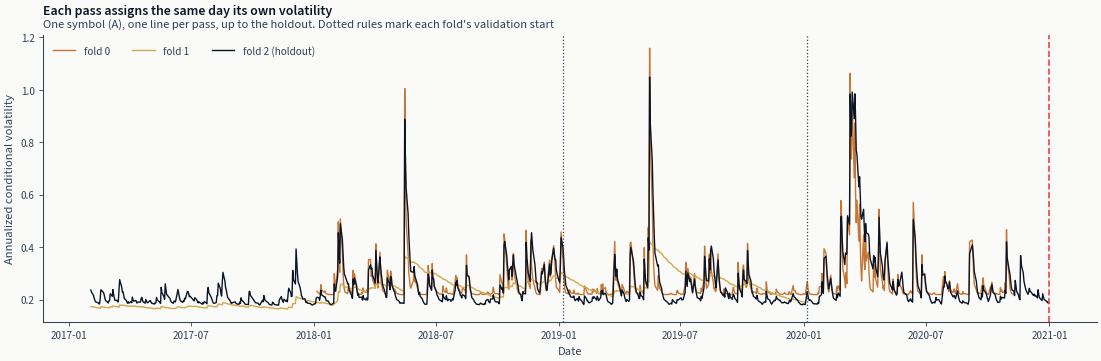

In [22]:
_drawn = before_holdout(garch_df)
_symbol = _drawn.group_by("symbol").len().sort(["len", "symbol"], descending=[True, False])
_symbol = _symbol["symbol"][0]
fig, ax = plt.subplots(figsize=(11, 3.6))
_pass_color = [COLORS["copper"], COLORS["amber"], COLORS["blue"]]
for _fold_id in sorted(_drawn["fold"].unique().to_list()):
    _path = _drawn.filter((pl.col("symbol") == _symbol) & (pl.col("fold") == _fold_id)).sort(
        "timestamp"
    )
    ax.plot(
        _path["timestamp"].to_list(),
        _path["garch_cond_vol"].to_list(),
        color=_pass_color[_fold_id % len(_pass_color)],
        linewidth=1.0,
        label=f"fold {_fold_id}" + (" (holdout)" if _fold_id == HOLDOUT_FOLD else ""),
    )
for fold in cv_folds:
    ax.axvline(
        pd.Timestamp(fold["val_start"]).date(),
        color=COLORS["neutral"],
        linestyle=":",
        linewidth=0.9,
    )
ax.axvline(
    pd.Timestamp(holdout_start).date(), color=COLORS["negative"], linestyle="--", linewidth=1.2
)
ax.set(xlabel="Date", ylabel="Annualized conditional volatility")
ax.legend(loc="upper left", frameon=False, fontsize=8, ncol=3)
add_message_title(
    ax,
    "Each pass assigns the same day its own volatility",
    subtitle=(
        f"One symbol ({_symbol}), one line per pass, up to the holdout. Dotted rules mark each "
        "fold's validation start"
    ),
)
show_with_alt(
    fig,
    f"Line chart of annualized conditional volatility for one symbol ({_symbol}) from early "
    "2017 to the start of 2021, with one line per pass drawn over the same dates. The series "
    "is spiky, sitting near 0.2 for long stretches and rising above 1.0 on three dates - May "
    "2018, May 2019 and March 2020 - the largest being May 2019 at about 1.16. The March 2020 "
    "one sits inside a sustained cluster of high readings that runs from late February into "
    "June. Where two passes cover the same day their lines sit close but not on top of each "
    "other, so each pass assigns the day its own value. Dotted vertical rules mark each fold's "
    "validation start and a dashed red rule marks the holdout, which no line crosses.",
)

### C.2 Stochastic volatility

GARCH makes yesterday's return determine today's variance exactly. A stochastic-volatility model
drops that: log-variance follows its own random walk, which nothing observes directly, and the
return is drawn around it.

$$h_{t} = h_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)$$
$$r_t \sim \mathcal{N}(0, \exp(h_t))$$

The one free parameter, $\sigma_\eta$, says how far the volatility level is allowed to drift from
one day to the next. Small values give a volatility that changes slowly; large values let it jump
to accommodate a single big return.

The model costs more than GARCH in two ways, and both shape what follows. Its likelihood has no
closed form, because every unobserved $h_t$ has to be integrated out, so $\sigma_\eta$ is
estimated by drawing from the posterior with Markov chain Monte Carlo rather than by maximizing
anything. And once $\sigma_\eta$ is fixed, recovering the daily $h_t$ needs a second algorithm:
a particle filter, which carries a population of candidate values forward and reweights them
against each day's return.

The split follows the same discipline as GARCH. $\sigma_\eta$ is a property of how equity
volatility behaves rather than of any one company, so it is estimated once per training window on
a small pool of symbols and then held fixed while every segment is filtered.

#### Which symbols the parameter is estimated on

The pool is chosen by option coverage *inside the training window* - the symbols with the most
dates carrying a straddle quote there - and not by coverage over the whole sample. Choosing on
whole-sample coverage would be a mild but real leak: which symbols stayed liquid through the
validation period is information from the validation period.

In [23]:
def option_coverage_in_window(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    start_date: date,
    end_date: date,
) -> pl.DataFrame:
    """Count observed option dates per identity inside one training window."""
    in_training = pl.col("timestamp").is_between(start_date, end_date, closed="both")
    return (
        option_panel.filter(in_training)
        .select(["timestamp", "symbol"])
        .unique()
        .join(
            identity_panel.select(["timestamp", "symbol", "sec_id"]).unique(),
            on=["timestamp", "symbol"],
            how="inner",
        )
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_option_days"))
    )

In [24]:
def return_coverage_in_window(
    return_panel: pl.DataFrame, start_date: date, end_date: date
) -> pl.DataFrame:
    """Count eligible return observations per identity inside a training window."""
    return (
        return_panel.filter(pl.col("timestamp").is_between(start_date, end_date, closed="both"))
        .group_by(["symbol", "sec_id"])
        .agg(pl.len().alias("n_return_days"))
        .filter(pl.col("n_return_days") >= 252)
    )

In [25]:
def select_sv_pool(
    option_panel: pl.DataFrame,
    identity_panel: pl.DataFrame,
    return_panel: pl.DataFrame,
    train_start: date,
    train_end: date,
    pool_size: int,
) -> list[tuple[str, int]]:
    """Select segments by training-window option coverage and return eligibility."""
    start_date, end_date = pd.Timestamp(train_start).date(), pd.Timestamp(train_end).date()
    option_coverage = option_coverage_in_window(option_panel, identity_panel, start_date, end_date)
    return_coverage = return_coverage_in_window(return_panel, start_date, end_date)
    selected = (
        option_coverage.join(return_coverage, on=["symbol", "sec_id"], how="inner")
        .sort(
            ["n_option_days", "n_return_days", "symbol", "sec_id"],
            descending=[True, True, False, False],
        )
        .head(pool_size)
    )
    if selected.height < pool_size:
        raise RuntimeError(
            f"Only {selected.height} security segments have 252 training observations"
        )
    return [(row["symbol"], int(row["sec_id"])) for row in selected.iter_rows(named=True)]

Both the sampler and the filter need random numbers, and the obvious way to supply them - one
generator advanced through the loop - makes every segment's result depend on how many segments
came before it. Adding one symbol to the universe would then change the filtered path of every
symbol after it in the loop, and none of those changes would be visible in a diff. Deriving each
stream's seed from the segment's own identity removes the dependence: a segment's numbers are the
same whatever else is in the run.

In [26]:
def stable_segment_seed(base_seed: int, namespace: str, symbol: str, sec_id: int) -> int:
    """Derive a stable unsigned 32-bit seed from model and security identity."""
    payload = f"{base_seed}|{namespace}|{symbol}|{sec_id}".encode()
    return int.from_bytes(hashlib.blake2s(payload, digest_size=4).digest(), "big")

#### Estimating the parameter

Each pool symbol contributes the last year of returns inside the training window, and the
sampler returns a posterior distribution for $\sigma_\eta$ rather than a point. The estimate the
filter uses is the mean of each symbol's posterior mean, weighted equally, so that a symbol whose
second, longer attempt produced more draws does not count for more than one that converged first
time.

A Monte Carlo sampler can return draws even when it has not converged, and they look like
ordinary draws. Four checks decide whether a symbol's posterior is used at all, and a symbol that
fails them after one longer retry stops the notebook rather than being quietly dropped:

- **R-hat** compares the variance between chains with the variance within them. It equals one
  when the chains are exploring the same distribution, and the gate below rejects anything
  meaningfully above that.
- **Effective sample size**, in the bulk and in the tails of the posterior. Consecutive draws are
  correlated, so two thousand draws are worth fewer than two thousand independent ones; the gate
  asks for at least four hundred independent-equivalent draws before it trusts a posterior mean.
- **Divergences** are steps the sampler's integrator is known to have got wrong. Any at all mean
  part of the posterior was never visited.
- **Maximum tree depth hits** mean the sampler ran out of allowed steps before it finished a
  trajectory, which makes the draws it did take unrepresentative.

In [27]:
def fit_sv_calibration_symbol(
    train_returns: np.ndarray,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float]]:
    """Sample one security segment's SV calibration posterior and diagnostics."""
    with pm.Model():
        sigma_eta = pm.Exponential("sigma_eta", lam=2)
        h0 = pm.Normal("h0", mu=0, sigma=1)
        innovations = pm.Normal("innovations", mu=0, sigma=1, shape=len(train_returns) - 1)
        h = pm.Deterministic(
            "h",
            pt.concatenate([h0[None], h0 + sigma_eta * pt.cumsum(innovations)]),
        )
        volatility = pm.Deterministic("volatility", pm.math.exp(h / 2))
        pm.Normal("obs", mu=0, sigma=volatility, observed=train_returns)
        trace = pm.sample(
            n_draws,
            tune=n_tune,
            chains=n_chains,
            cores=n_chains,
            progressbar=False,
            random_seed=seed,
            target_accept=SV_TARGET_ACCEPT,
        )

    return trace.posterior["sigma_eta"].values.flatten(), summarize_sv_trace(trace)

In [28]:
def summarize_sv_trace(trace) -> dict[str, float]:
    """Extract every hard-gate diagnostic from one accepted trace candidate."""
    sample_stats = trace.sample_stats
    if "reached_max_treedepth" in sample_stats:
        max_treedepth_hits = int(sample_stats["reached_max_treedepth"].values.sum())
    else:
        max_treedepth_hits = int((sample_stats["tree_depth"].values >= 10).sum())
    return {
        "rhat": float(az.rhat(trace, var_names=["sigma_eta"], method="rank")["sigma_eta"].item()),
        "ess_bulk": float(
            az.ess(trace, var_names=["sigma_eta"], method="bulk")["sigma_eta"].item()
        ),
        "ess_tail": float(
            az.ess(trace, var_names=["sigma_eta"], method="tail")["sigma_eta"].item()
        ),
        "divergences": int(sample_stats["diverging"].values.sum()),
        "max_treedepth_hits": max_treedepth_hits,
    }

In [29]:
def sv_diagnostics_pass(diagnostics: dict[str, float]) -> bool:
    """Return whether one SV posterior clears every hard calibration gate."""
    return bool(
        diagnostics["rhat"] <= 1.01
        and diagnostics["ess_bulk"] >= 400
        and diagnostics["ess_tail"] >= 400
        and diagnostics["divergences"] == 0
        and diagnostics["max_treedepth_hits"] == 0
    )

In [30]:
def run_sv_calibration_attempt(
    train_data: pd.Series,
    draws: int,
    tune: int,
    chains: int,
    seed: int,
    attempt: int,
) -> tuple[np.ndarray | None, dict[str, float] | None, dict]:
    """Run one SV calibration attempt and retain failure evidence."""
    try:
        pool, diagnostics = fit_sv_calibration_symbol(
            train_data.to_numpy(), draws, tune, chains, seed
        )
        return pool, diagnostics, {"attempt": attempt, "draws": draws, "tune": tune, **diagnostics}
    except Exception as exc:
        record = {
            "attempt": attempt,
            "draws": draws,
            "tune": tune,
            "error": f"{type(exc).__name__}: {exc}",
        }
        return None, None, record

In [31]:
def accepted_sv_calibration(
    symbol: str,
    train_data: pd.Series,
    n_draws: int,
    n_tune: int,
    n_chains: int,
    seed: int,
) -> tuple[np.ndarray, dict[str, float], list[dict]]:
    """Retry once and fail closed unless every SV diagnostic passes."""
    pool, diagnostics, first = run_sv_calibration_attempt(
        train_data, n_draws, n_tune, n_chains, seed, 1
    )
    attempts = [first]
    if pool is None or diagnostics is None or not sv_diagnostics_pass(diagnostics):
        print(
            f"    {symbol}: initial SV gate failed; retrying with "
            f"{SV_RETRY_TUNE:,} tune + {SV_RETRY_DRAWS:,} draws"
        )
        pool, diagnostics, retry = run_sv_calibration_attempt(
            train_data, SV_RETRY_DRAWS, SV_RETRY_TUNE, n_chains, seed, 2
        )
        attempts.append(retry)
    if pool is None or diagnostics is None:
        raise RuntimeError(f"SV retry failed for {symbol}: {attempts}")
    if not sv_diagnostics_pass(diagnostics):
        raise RuntimeError(f"SV convergence gate failed after retry for {symbol}: {attempts}")
    return pool, diagnostics, attempts

In [32]:
def sv_training_window(
    segment_returns: dict[tuple[str, int], pd.Series],
    segment_key: tuple[str, int],
    train_start: pd.Timestamp,
    train_end: pd.Timestamp,
) -> pd.Series:
    """Return one segment's trailing 252 observations inside the fit window."""
    if segment_key not in segment_returns:
        raise RuntimeError(f"Missing returns for SV calibration segment {segment_key}")
    returns = segment_returns[segment_key]
    train_data = returns[(returns.index >= train_start) & (returns.index <= train_end)].tail(252)
    if len(train_data) < 252:
        raise RuntimeError(
            f"SV calibration segment {segment_key} has only {len(train_data)} training observations"
        )
    return train_data

In [33]:
def sv_calibration_diagnostic(
    symbol: str,
    sec_id: int,
    train_data: pd.Series,
    pool: np.ndarray,
    diagnostics: dict[str, float],
    attempts: list[dict],
) -> dict:
    """Record one accepted segment calibration with its complete audit trail."""
    segment_mean = float(np.mean(pool))
    return {
        "symbol": symbol,
        "sec_id": sec_id,
        "fit_start": train_data.index.min(),
        "fit_end": train_data.index.max(),
        "n_fit": len(train_data),
        "sigma_eta": segment_mean,
        "retried": len(attempts) == 2,
        "attempts": attempts,
        **diagnostics,
    }

Both ends of the estimation window are passed in by the caller. A default that took everything up
to a cut-off would quietly turn the rolling window the folds define into an expanding one, and the
difference would not show up in any value.

In [34]:
def calibrate_sigma_eta(
    pool_segments: list[tuple[str, int]],
    segment_returns: dict[tuple[str, int], pd.Series],
    train_start: date,
    train_end: date,
    n_draws: int = 500,
    n_tune: int = 300,
    n_chains: int = 2,
) -> tuple[float, list[dict]]:
    """Estimate equal-segment-weighted sigma_eta in one training window."""
    diagnostics = []
    train_start_ts = pd.Timestamp(train_start)
    train_end_ts = pd.Timestamp(train_end)
    calibration_namespace = f"calibration:{train_start_ts.date()}:{train_end_ts.date()}"
    for symbol, sec_id in pool_segments:
        segment_key = (symbol, sec_id)
        train_data = sv_training_window(segment_returns, segment_key, train_start_ts, train_end_ts)
        seed = stable_segment_seed(SEED, calibration_namespace, symbol, sec_id)
        pool, diag, attempts = accepted_sv_calibration(
            symbol, train_data, n_draws, n_tune, n_chains, seed
        )
        record = sv_calibration_diagnostic(symbol, sec_id, train_data, pool, diag, attempts)
        diagnostics.append(record)
        print(
            f"    {symbol}: sigma_eta={record['sigma_eta']:.4f}, "
            f"R-hat={diag['rhat']:.4f}, bulk ESS={diag['ess_bulk']:.0f}, "
            f"tail ESS={diag['ess_tail']:.0f}, divergences={diag['divergences']}, "
            f"attempts={len(attempts)}"
        )
    if not diagnostics:
        raise RuntimeError("All SV calibration fits failed")
    pooled = float(np.mean([record["sigma_eta"] for record in diagnostics]))
    print(f"  Pooled sigma_eta: {pooled:.4f} ({len(diagnostics)} successful segments)")
    return pooled, diagnostics

#### Recovering the daily volatility

With $\sigma_\eta$ fixed, the filter walks through one segment's returns one day at a time,
carrying a thousand candidate values of the unobserved log-variance. On each day it does three
things: score each candidate by how likely it makes that day's return, draw a new population from
the scored one so that candidates explaining the return well are represented more often, and push
every candidate forward by one random-walk step.

What is written out is the average candidate volatility **before** the day's return is scored -
an expectation conditioned on returns up to yesterday. That is the same information set GARCH's
conditional variance uses, which is what makes the two columns comparable, and it is also what
makes a value on any date usable by a strategy deciding on that date.

In [35]:
def particle_filter_sv(
    returns: np.ndarray,
    sigma_eta: float,
    n_particles: int = 1000,
    seed: int = 42,
) -> np.ndarray:
    """Return annualized one-step-ahead volatility using information through t-1."""
    rng = np.random.default_rng(seed)
    T = len(returns)
    particles = rng.normal(0, 1, size=n_particles)
    predicted_vol = np.empty(T)
    for t in range(T):
        # One-step-ahead prediction: E[exp(h_t/2) | r_{1:t-1}]
        # (particles represent the prediction distribution before seeing r_t)
        predicted_vol[t] = np.mean(np.exp(particles / 2))

        log_w = -0.5 * particles - 0.5 * returns[t] ** 2 * np.exp(-particles)
        log_w -= log_w.max()
        w = np.exp(log_w)
        w_sum = w.sum()
        if w_sum == 0:
            w[:] = 1.0 / n_particles
        else:
            w /= w_sum

        cumsum = np.cumsum(w)
        positions = (rng.random() + np.arange(n_particles)) / n_particles
        indices = np.searchsorted(cumsum, positions).clip(0, n_particles - 1)
        particles = particles[indices]

        particles += rng.normal(0, sigma_eta, size=n_particles)
    return predicted_vol / 100 * np.sqrt(PERIODS_PER_YEAR)

#### The same passes as GARCH

One estimate of $\sigma_\eta$ per pass, then every segment filtered under it. The filter is
started at each segment's first available return rather than at the pass's start date, because a
particle population needs a run of observations before it concentrates anywhere useful; the
values from that run-in are discarded and only the pass's own window is kept.

In [36]:
def filter_sv_segments(
    segment_returns: dict[tuple[str, int], pd.Series],
    sigma_eta: float,
    filter_end: date | str,
    output_start: date | str,
    output_end: date | str,
    namespace: str,
    fold: int,
) -> list[pl.DataFrame]:
    """Particle-filter every segment and retain the requested output window."""
    features = []
    output_start_ts, output_end_ts = map(pd.Timestamp, (output_start, output_end))
    for (symbol, sec_id), returns in segment_returns.items():
        filter_returns = returns[returns.index <= pd.Timestamp(filter_end)]
        path = particle_filter_sv(
            filter_returns.values,
            sigma_eta,
            SV_N_PARTICLES,
            seed=stable_segment_seed(SEED, namespace, symbol, sec_id),
        )
        volatility = pd.Series(path, index=filter_returns.index)
        selected = volatility[
            (volatility.index >= output_start_ts) & (volatility.index <= output_end_ts)
        ]
        if selected.empty:
            continue
        features.append(
            pl.DataFrame(
                {
                    "timestamp": selected.index.values,
                    "symbol": symbol,
                    "sec_id": sec_id,
                    "sv_vol": selected.values,
                    "fold": fold,
                }
            )
        )
    return features

In [37]:
sv_results = []
sv_calibration = []
_sv_passes = [
    (
        fold["fold"],
        fold["train_start"],
        fold["train_end"],
        fold["train_start"],
        fold["val_end"],
        f"cv-fold:{fold['fold']}",
    )
    for fold in cv_folds
] + [
    (
        HOLDOUT_FOLD,
        pd.Timestamp(data_start),
        pd.Timestamp(holdout_train_end),
        pd.Timestamp(data_start),
        pd.Timestamp(holdout_end),
        "holdout",
    )
]

for fold_idx, train_start, train_end, output_start, output_end, namespace in _sv_passes:
    sv_pool = select_sv_pool(
        prices, reconciled_returns, returns_df, train_start, train_end, SV_POOL_SIZE
    )
    print(
        f"\n--- SV fold {fold_idx}: {len(sv_pool)} symbols, estimated on "
        f"{train_start.date()}..{train_end.date()} ---"
    )
    sigma_eta_est, sigma_eta_diagnostics = calibrate_sigma_eta(
        sv_pool,
        segment_returns,
        train_start,
        train_end,
        n_draws=SV_DRAWS,
        n_tune=SV_TUNE,
        n_chains=SV_CHAINS,
    )
    sv_calibration.append(
        {
            "fold": fold_idx,
            "sigma_eta": sigma_eta_est,
            "pool_symbols": len(sv_pool),
            "retried": sum(record["retried"] for record in sigma_eta_diagnostics),
        }
    )
    print(f"  Filtering {len(segment_returns)} segments")
    fold_results = filter_sv_segments(
        segment_returns,
        sigma_eta_est,
        output_end,
        output_start,
        output_end,
        namespace,
        fold_idx,
    )
    sv_results.extend(fold_results)
    print(f"  Filtered: {len(fold_results)} segments")


--- SV fold 0: 10 symbols, estimated on 2018-01-05..2019-11-12 ---


    AMD: sigma_eta=0.3363, R-hat=1.0006, bulk ESS=2421, tail ESS=4094, divergences=0, attempts=1


    AMZN: sigma_eta=0.2074, R-hat=1.0004, bulk ESS=2530, tail ESS=4796, divergences=0, attempts=1


    AZO: sigma_eta=0.1928, R-hat=1.0012, bulk ESS=2149, tail ESS=2728, divergences=0, attempts=1


    BA: sigma_eta=0.1256, R-hat=1.0074, bulk ESS=754, tail ESS=2137, divergences=0, attempts=1


...

    NVDA: sigma_eta=0.2540, R-hat=1.0000, bulk ESS=3815, tail ESS=5501, divergences=0, attempts=1


    AAPL: sigma_eta=0.2807, R-hat=1.0012, bulk ESS=2795, tail ESS=5335, divergences=0, attempts=1


    BAC: sigma_eta=0.3030, R-hat=1.0005, bulk ESS=2650, tail ESS=4589, divergences=0, attempts=1


    MU: sigma_eta=0.1959, R-hat=1.0019, bulk ESS=3729, tail ESS=5310, divergences=0, attempts=1
  Pooled sigma_eta: 0.2815 (10 successful segments)
  Filtering 620 segments


  Filtered: 620 segments


In [38]:
if not sv_results:
    raise RuntimeError("No stochastic-volatility filter produced a feature panel")
sv_df = pl.concat(sv_results).with_columns(pl.col("timestamp").cast(pl.Date))
validate_segment_feature_panel(sv_df, "sv_vol")
print(f"\nSV panel: {sv_df.height:,} rows, {sv_df['symbol'].n_unique()} symbols")
print(
    f"  Mean annualized volatility before the holdout: {before_holdout(sv_df)['sv_vol'].mean():.4f}"
)

  Coverage guard: 620 segments, 609 symbols, unique output keys

SV panel: 1,350,180 rows, 609 symbols
  Mean annualized volatility before the holdout: 0.2863


## D. Fit stability across folds

Re-estimating the models at every fold boundary is only worth its cost if the estimates move. It
is also a risk: parameters that swing from one window to the next make the feature they produce a
different quantity in each fold, and a model trained across folds then sees one column meaning
several things.

Three readings, in order of how directly they bear on that. Whether the optimizer converged at
all, which bounds how much of the panel any of this describes. Whether the fitted parameters
themselves moved. And whether the values the parameters produce moved, which is the question that
actually matters and is not answered by the second.

In [39]:
garch_fits = pl.DataFrame(garch_diagnostics)
fit_summary = (
    garch_fits.group_by("fold")
    .agg(
        pl.len().alias("garch_attempted"),
        pl.col("converged").sum().alias("garch_converged"),
        pl.col("persistence").median().alias("median_persistence"),
    )
    .sort("fold")
)
sv_summary = pl.DataFrame(sv_calibration).sort("fold")
fit_summary.join(
    sv_summary.select(
        "fold",
        pl.col("pool_symbols").alias("mcmc_symbols"),
        pl.col("retried").alias("mcmc_retried"),
        "sigma_eta",
    ),
    on="fold",
)

fold,garch_attempted,garch_converged,median_persistence,mcmc_symbols,mcmc_retried,sigma_eta
i64,u32,u32,f64,i64,i64,f64
0,496,495,0.86887,10,0,0.202327
1,500,497,0.908874,10,0,0.281106
2,563,561,0.964667,10,0,0.281477


### Figure F3. Do the fitted parameters move as the window rolls?

The GARCH parameter worth watching is **persistence**, $\alpha + \gamma/2 + \beta$: the share of
today's variance that carries into tomorrow. The lower it is, the faster a volatility shock
decays. As it approaches one the shock never decays at all, and at one the long-run variance the
model implies stops existing. The dashed line marks that boundary.

One box per pass, over the persistences fitted for every converged segment in it. Two things
separate the passes, and the figure cannot tell them apart: the windows sit at different points in
the sample, and the holdout pass's window is roughly twice as long as either fold's. A longer
window contains more distinct volatility regimes, and a single set of GARCH parameters can only
absorb that by raising persistence - which is what makes the last box the highest and the
tightest, not anything about the period it happens to cover.

Note also what a box plot cannot show. Two passes whose distributions coincided would still be
consistent with every individual symbol's parameters moving, as long as they moved in both
directions. Figure F2 asked the per-symbol question directly, on the filtered values rather than
on the parameters, and the measurement below closes it.

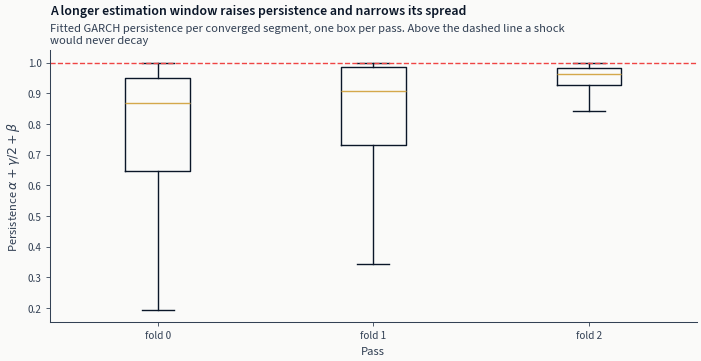

In [40]:
_persist = garch_fits.filter(pl.col("converged") & pl.col("persistence").is_not_null())
fig, ax = plt.subplots(figsize=(7, 3.6))
_fold_ids = sorted(_persist["fold"].unique().to_list())
_samples = [_persist.filter(pl.col("fold") == f)["persistence"].to_list() for f in _fold_ids]
ax.boxplot(_samples, tick_labels=[f"fold {f}" for f in _fold_ids], showfliers=False)
ax.axhline(1.0, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set(xlabel="Pass", ylabel=r"Persistence $\alpha + \gamma/2 + \beta$")
add_message_title(
    ax,
    "A longer estimation window raises persistence and narrows its spread",
    subtitle=(
        "Fitted GARCH persistence per converged segment, one box per pass. Above the dashed line "
        "a shock would never decay"
    ),
)
show_with_alt(
    fig,
    "Box plot of fitted GARCH persistence, alpha plus gamma over two plus beta, with one box "
    "per pass. Fold 0 is the widest, its whiskers running from about 0.20 to 1.00 with a "
    "median near 0.87; fold 1 is narrower, from about 0.34 upward with a median near 0.91; "
    "fold 2 is tightest, from about 0.84 upward with a median near 0.97. A dashed red line at "
    "1.0 marks where a shock would never decay, and all three upper whiskers reach it. So a "
    "longer estimation window both raises the central persistence and narrows its spread, "
    "without moving the top of the range.",
)

The comparison figure F2 drew for one symbol is worth putting a number on across all of them.
For every symbol and date covered by more than one pass, the spread between the values those
passes assign, against the size of an ordinary one-day move within a single pass. Both are read
before the holdout. If refitting moved nothing, the first would be far smaller than the second.

In [41]:
_shared = (
    before_holdout(garch_df)
    .group_by(["symbol", "timestamp"])
    .agg(
        (pl.col("garch_cond_vol").max() - pl.col("garch_cond_vol").min()).alias("spread"),
        pl.len().alias("n_passes"),
    )
    .filter(pl.col("n_passes") > 1)
)
_daily_move = (
    before_holdout(garch_df)
    .sort(["fold", "symbol", "timestamp"])
    .with_columns(pl.col("garch_cond_vol").diff().abs().over(["fold", "symbol"]).alias("move"))
    .drop_nulls("move")
)
pass_spread = float(_shared["spread"].median())
daily_move = float(_daily_move["move"].median())
persistence_iqr = float(
    np.median(
        [np.subtract(*np.percentile(sample, [75, 25])) for sample in _samples if len(sample) > 1]
    )
)
print(f"Median disagreement between passes on a shared day: {pass_spread:.4f}")
print(f"Median absolute one-day move within a pass:         {daily_move:.4f}")
print(f"Ratio: {pass_spread / daily_move:.1f}x")
print(f"\nMedian GARCH persistence by pass: {fit_summary['median_persistence'].round(3).to_list()}")
print(f"Typical within-pass interquartile range: {persistence_iqr:.3f}")
print(f"Estimated sigma_eta by pass:      {sv_summary['sigma_eta'].round(4).to_list()}")

Median disagreement between passes on a shared day: 0.0319
Median absolute one-day move within a pass:         0.0067
Ratio: 4.7x

Median GARCH persistence by pass: [0.869, 0.909, 0.965]
Typical within-pass interquartile range: 0.258
Estimated sigma_eta by pass:      [0.2023, 0.2811, 0.2815]


Almost every fit converges: **495 of 496** segments in fold 0, **497 of 500** in fold 1 and
**561 of 563** in the holdout pass, and no calibration needed its longer second attempt. So the
panel below rests on the whole eligible universe rather than on the subset the optimizer happened
to like.

Refitting moves the feature. Median GARCH persistence runs **0.869**, **0.909**, **0.965** across
the three passes, against a typical within-pass interquartile range of **0.258** - so symbols
still differ from each other more than the windows differ. But on the values, where it counts, two
passes disagree about the same symbol on the same day by a median **0.0319** in annualized
volatility, which is **4.7** times the median one-day move of **0.0067** within a single pass. The
vol-of-vol parameter moves the same way, **0.2023** to **0.2815**.

Read together: a model trained on one fold and scored on another would be reading a column that
does not mean the same thing in both, which is exactly why the fold identifier is written beside
the values and why every downstream join carries it.

## E. Combine and emit

Four columns are written. Two are the volatilities the models produced. The other two are each
model's forecast subtracted from the at-the-money implied volatility quoted on the same symbol
and date - the **variance risk premium**, the amount by which the option market's price for the
next month of volatility exceeds what a model fitted on the underlying's own history expects.
A positive value is what a seller of that straddle is being paid for; whether it is enough to
cover what selling it costs is the question the rest of the case study asks.

The join back to the quote panel is on symbol and date only, because implied volatility is a
property of the quote rather than of the pass, and the same quote is therefore differenced
against each pass's forecast. A symbol and date the models covered but the option panel did not
quote leaves both premium columns null rather than dropping the row: the volatility columns are
still defined there and a later stage may want them.

In [42]:
temporal = (
    garch_df.join(
        sv_df.select(["timestamp", "symbol", "sec_id", "fold", "sv_vol"]),
        on=["timestamp", "symbol", "sec_id", "fold"],
        how="left",
    )
    .join(prices.select(["timestamp", "symbol", "iv_atm"]), on=["timestamp", "symbol"], how="left")
    .with_columns(
        (pl.col("iv_atm") - pl.col("garch_cond_vol")).alias("garch_vrp"),
        (pl.col("iv_atm") - pl.col("sv_vol")).alias("sv_vrp"),
    )
    .drop(["iv_atm", "sec_id"])
    .with_columns(pl.col("fold").cast(pl.Int32))
)

Downstream notebooks read this file by column name and dtype, so both are pinned here and
checked before anything is written. A column silently renamed or promoted from 32-bit to 64-bit
is the kind of change that surfaces as a join returning nulls three notebooks later.

In [43]:
MODEL_BASED_SCHEMA = {
    "timestamp": pl.Date,
    "symbol": pl.String,
    "garch_cond_vol": pl.Float64,
    "fold": pl.Int32,
    "sv_vol": pl.Float64,
    "garch_vrp": pl.Float64,
    "sv_vrp": pl.Float64,
}


def validate_public_temporal_schema(frame: pl.DataFrame) -> None:
    """Fail before write when public schema, order, or keys drift."""
    if frame.columns != list(MODEL_BASED_SCHEMA):
        raise RuntimeError(f"Unexpected model_based columns: {frame.columns}")
    if dict(frame.schema) != MODEL_BASED_SCHEMA:
        raise RuntimeError(f"Unexpected model_based schema: {frame.schema}")
    duplicate_keys = int(frame.select(["timestamp", "symbol", "fold"]).is_duplicated().sum())
    if duplicate_keys:
        raise RuntimeError(f"Combined temporal panel contains {duplicate_keys} duplicate keys")

In [44]:
validate_public_temporal_schema(temporal)

feature_cols = [c for c in temporal.columns if c not in ("timestamp", "symbol", "fold")]
print(f"Columns written: {feature_cols}")

per_pass = (
    temporal.group_by("fold")
    .agg(
        pl.len().alias("rows"),
        pl.col("timestamp").min().alias("first_date"),
        pl.col("timestamp").max().alias("last_date"),
        pl.col("symbol").n_unique().alias("symbols"),
    )
    .join(
        # How often a column has no value is a measurement of the data rather than a fact about
        # the file's shape, so it is counted before the holdout like every other measurement here.
        before_holdout(temporal)
        .group_by("fold")
        .agg(*[pl.col(c).null_count().alias(f"null_{c}") for c in ("sv_vol", "garch_vrp")]),
        on="fold",
    )
    .sort("fold")
)
per_pass

Columns written: ['garch_cond_vol', 'sv_vol', 'garch_vrp', 'sv_vrp']


fold,rows,first_date,last_date,symbols,null_sv_vol,null_garch_vrp
i32,u32,date,date,u32,u32,u32
0,340999,2018-01-05,2020-11-10,495,0,138189
1,349695,2017-02-02,2020-01-03,497,0,140690
2,606395,2017-02-02,2021-12-31,556,0,207167


The first four columns are the shape of what was written, which is fixed by the fold windows in
`setup.yaml`. The two null counts are a measurement and so are taken before the holdout: they
count where the premium columns have no value, which happens wherever the straddle panel carried
no quote on a date the underlying traded. The volatility columns are never null - both models
write a value for every date in their pass, and the check before the write would have stopped the
notebook otherwise.

### E.1 Writing the file

The parquet goes out beside a small JSON file recording a hash of the parquet's contents, its row
count, the columns and keys it carries, and the same hash for each thing it was built from. Two
runs that produce different values therefore produce different hashes, which is what lets a later
stage tell whether the features a model was trained on are the features on disk now. The hash is
taken over the content rather than the file bytes, so re-writing the same values in a different
row order leaves it alone.

The straddle panel and the underlying bars are hashed here as they were read. `financial.parquet`
is not re-hashed: `03_financial_features` already wrote its hash beside it, and reading that
forward is what makes the chain a chain.

In [45]:
record = write_artifact(
    temporal,
    FEATURES_DIR / "model_based.parquet",
    keys=["timestamp", "symbol", "fold"],
    written_by="case_studies/sp500_options/04_model_based_features.py",
    inputs={
        "features/financial.parquet": read_digest(FEATURES_DIR / "financial.parquet")["digest"],
        "load_sp500_options_straddles": value_digest(
            prices.select(["timestamp", "symbol", "iv_atm"])
        ),
        "load_sp500_daily_bars": value_digest(returns_df),
    },
)
print(f"Wrote model_based.parquet: {temporal.height:,} rows, digest {record['digest']}")

Wrote model_based.parquet: 1,297,089 rows, digest 5f97b6f2e3eb3397


## F. Incremental evaluation

The four columns are written whatever they turn out to be worth; deciding which features a model
gets is stage 05's job over the whole set. What this section asks is narrower and belongs next to
the models that produced the columns. On validation dates only: does sorting symbols by one of
these columns sort them by the return the strategy actually earned, and does it do so any better
than the features stage 03 already wrote?

The measure is the **information coefficient** - the rank correlation, computed across the symbols
quoted on a single date, between the feature and the outcome of a position opened that date. One
correlation per date gives a series, and the series is what is tested. The stage-03 features are
put through the identical procedure on the identical rows, so "incremental" is something the
figure shows rather than something the text asserts. The holdout contributes to none of it.

In [46]:
label_col = _setup["labels"]["primary"]
primary_label_df = pl.read_parquet(LABELS_DIR / f"{label_col}.parquet")
print(f"Label: {label_col}, {primary_label_df.height:,} rows")

Label: ret_to_expiry, 353,742 rows


Restricting to validation dates is not sufficient on its own, because what makes a row holdout
information is when its position *resolves*, not when it was opened. A straddle sold in the last
weeks of a validation window runs to an expiry that can fall after the window closes, and if it
falls past the start of the holdout then its outcome is a holdout observation whatever date the
position was opened on.

The cut is therefore made per row, on each straddle's own calendar days to expiry, rather than by
subtracting one horizon from every row - the contract's life varies from row to row and a single
subtraction would be right for none of them. The count below is the check, not a repair: the label
buffer that separates each fold's training and validation windows already ends the last validation
window far enough before the holdout, and the point of computing the endpoint is to establish that
rather than assume it.

In [47]:
def seal_incremental_label_endpoints(
    frame: pl.DataFrame, holdout_start_date: date
) -> tuple[pl.DataFrame, int, date | None]:
    """Remove validation labels whose realized endpoint enters the holdout."""
    if frame["dte_calendar"].null_count():
        raise RuntimeError("Incremental evaluation contains null dte_calendar")
    with_endpoint = frame.with_columns(
        (pl.col("timestamp") + pl.duration(days=pl.col("dte_calendar"))).alias("label_endpoint")
    )
    purged_rows = with_endpoint.filter(pl.col("label_endpoint") >= holdout_start_date).height
    retained = with_endpoint.filter(pl.col("label_endpoint") < holdout_start_date)
    return retained, purged_rows, retained["label_endpoint"].max()

Each fold contributes only its own validation window, taken from its own pass. The holdout pass
contributes nothing.

In [48]:
temporal_eval = pl.concat(
    [
        temporal.filter(
            (pl.col("fold") == _fold["fold"])
            & (pl.col("timestamp") >= _fold["val_start"].date())
            & (pl.col("timestamp") <= _fold["val_end"].date())
        )
        for _fold in cv_folds
    ]
).drop("fold")

eval_data = temporal_eval.join(
    primary_label_df.select(["timestamp", "symbol", label_col, "dte_calendar"]),
    on=["timestamp", "symbol"],
    how="inner",
)
eval_data, n_endpoint_purged_rows, max_retained_label_endpoint = seal_incremental_label_endpoints(
    eval_data,
    date.fromisoformat(holdout_start),
)
print(
    f"Validation rows scored: {eval_data.height:,} "
    f"({eval_data['symbol'].n_unique()} symbols)\n"
    f"Rows dropped because the position resolved inside the holdout: "
    f"{n_endpoint_purged_rows:,}\n"
    f"Latest date any retained position resolves on: {max_retained_label_endpoint}"
)

Validation rows scored: 124,300 (487 symbols)
Rows dropped because the position resolved inside the holdout: 0
Latest date any retained position resolves on: 2020-12-11


### Two corrections the test needs

**Overlap.** Consecutive positions in this strategy are open at the same time: one opened this
Friday is still running when next Friday's is opened, and both are settled by the same market
moves. Their outcomes are correlated for that reason alone, so the daily IC series is
autocorrelated and an ordinary standard error - which assumes each day is fresh evidence - is too
small. Newey-West standard errors widen it by looking back far enough to absorb that correlation,
and the distance they look is set here by the holding period in `setup.yaml` rather than picked.
The table below reports both standard errors side by side, so how much the correction costs is
visible rather than asserted.

**Multiplicity.** Four features are screened against one label. Testing four things at a
conventional significance level and reporting whichever clears turns up a finding far more often
than that level suggests, even when there is nothing to find. The Benjamini-Hochberg procedure
adjusts each p-value for the size of the family it was drawn from, and the count of discoveries
is read off the adjusted values. The unadjusted ones stay in the table because they say how
strong each individual estimate is, but they decide nothing.

In [49]:
def summarize_temporal_ic(temporal_ic: dict[str, dict]) -> tuple[pl.DataFrame, int]:
    """Build the temporal IC table with BH-FDR correction across the family."""
    feature_names = list(temporal_ic)
    p_values = [float(temporal_ic[feature]["p_value"]) for feature in feature_names]
    fdr_result = benjamini_hochberg_fdr(p_values, alpha=0.05, return_details=True)
    summary = pl.DataFrame(
        {
            "feature": feature_names,
            "ic_mean": [temporal_ic[feature]["mean_ic"] for feature in feature_names],
            "naive_se": [temporal_ic[feature]["naive_se"] for feature in feature_names],
            "hac_se": [temporal_ic[feature]["hac_se"] for feature in feature_names],
            "hac_tstat": [temporal_ic[feature]["t_stat"] for feature in feature_names],
            "hac_pval": p_values,
            "fdr_pval": [float(value) for value in fdr_result["adjusted_p_values"]],
            "significant_fdr05": [bool(value) for value in fdr_result["rejected"]],
        }
    ).sort(pl.col("ic_mean").abs(), descending=True)
    return summary, int(fdr_result["n_rejected"])

A date is only scored when at least ten symbols were quoted on it. A rank correlation over three
or four names is decided by which of them happened to have a straddle listed, and a series of
such days would look like evidence while carrying none.

`cross_sectional_ic_series` returns the series sorted by date, which matters more than it looks:
`compute_ic_hac_stats` reads row order as time order and does not sort, and neither Polars
`group_by` nor `partition_by` returns groups in key order. A series assembled by grouping and
passed straight in gets a serial-correlation correction computed over an arbitrary permutation of
the calendar.

In [50]:
MIN_SYMBOLS_PER_DATE = 10


def compute_temporal_ic(frame: pl.DataFrame, features: list[str], target: str) -> dict[str, dict]:
    """Compute HAC-corrected IC statistics for each feature with adequate support."""
    temporal_ic = {}
    for feature in features:
        ic_series = cross_sectional_ic_series(
            frame,
            frame,
            pred_col=feature,
            ret_col=target,
            date_col="timestamp",
            entity_col="symbol",
            method="spearman",
            min_obs=MIN_SYMBOLS_PER_DATE,
        ).drop_nulls("ic")
        if ic_series.height < 10:
            continue
        hac_stats = compute_ic_hac_stats(
            ic_series,
            ic_col="ic",
            label_horizon=LABEL_HORIZON_TRADING_DAYS,
        )
        required = [hac_stats.get(key, float("nan")) for key in ("mean_ic", "t_stat", "p_value")]
        if all(np.isfinite(value) for value in required):
            temporal_ic[feature] = hac_stats
    return temporal_ic

In [51]:
def evaluate_incremental_temporal_features(
    frame: pl.DataFrame, features: list[str], target: str
) -> tuple[pl.DataFrame, int]:
    """Evaluate the temporal family and return its BH-corrected IC table."""
    if len(frame) < 20:
        raise RuntimeError(f"Incremental evaluation has only {len(frame)} overlapping rows")
    temporal_ic = compute_temporal_ic(frame, features, target)
    if not temporal_ic:
        raise RuntimeError("No temporal feature had enough non-null observations for IC")
    summary, discoveries = summarize_temporal_ic(temporal_ic)
    print(f"Discoveries at q < 0.05: {discoveries} of {len(temporal_ic)} features")
    return summary, discoveries

In [52]:
ic_summary, n_temporal_discoveries_fdr05 = evaluate_incremental_temporal_features(
    eval_data, feature_cols, label_col
)
ic_summary

Discoveries at q < 0.05: 0 of 4 features


feature,ic_mean,naive_se,hac_se,hac_tstat,hac_pval,fdr_pval,significant_fdr05
str,f64,f64,f64,f64,f64,f64,bool
"""sv_vrp""",0.008578,0.005281,0.013612,0.630143,0.52891,0.846434,false
"""sv_vol""",-0.008304,0.006664,0.019842,-0.418484,0.675786,0.846434,false
"""garch_vrp""",-0.003306,0.004603,0.012802,-0.258239,0.796336,0.846434,false
"""garch_cond_vol""",0.003235,0.005516,0.016694,0.193778,0.846434,0.846434,false


### The stage-03 features, on the same rows

"Incremental" only means something against a reference, so the features `03_financial_features`
wrote go through the same procedure on the same dates and symbols, against the same label. The
columns that file marks as position metadata rather than features - the prices a position is
valued at - are excluded, because a price is not a signal and would only widen the reference with
something nobody proposed to trade on.

In [53]:
_metadata_cols = set(_setup["features"]["metadata"])
financial_cols = [
    c
    for c in features.columns
    if c not in {"timestamp", "symbol", "instrument_id"} | _metadata_cols
]
financial_panel = features.select(["timestamp", "symbol", *financial_cols])
if financial_panel.select(["timestamp", "symbol"]).is_duplicated().any():
    raise RuntimeError("financial.parquet carries more than one row per symbol and date")

financial_eval = eval_data.select(["timestamp", "symbol", label_col]).join(
    financial_panel, on=["timestamp", "symbol"], how="inner"
)
financial_ic = compute_temporal_ic(financial_eval, financial_cols, label_col)
if not financial_ic:
    raise RuntimeError("No stage-03 feature had enough support to score on the validation rows")
financial_abs_ic = np.abs([stats["mean_ic"] for stats in financial_ic.values()])
IC_BAND_PERCENTILE = 90
print(
    f"Stage-03 features scored on the same rows: {len(financial_ic)} of {len(financial_cols)}\n"
    f"Their absolute mean IC: median {np.median(financial_abs_ic):.4f}, "
    f"{IC_BAND_PERCENTILE}th percentile "
    f"{np.percentile(financial_abs_ic, IC_BAND_PERCENTILE):.4f}, "
    f"largest {financial_abs_ic.max():.4f}"
)

Stage-03 features scored on the same rows: 47 of 47
Their absolute mean IC: median 0.0063, 90th percentile 0.0136, largest 0.0338


### Figure F4. What the screen found

The table above is the whole answer for the four new columns, and a table is the wrong shape for
it: reading whether an estimate is distinguishable from zero means holding four numbers in mind at
once. Drawn as an estimate with its interval, the interval either crosses zero or it does not.

The grey band is where the stage-03 features sit: nine in ten of them have an absolute mean IC
inside it. A new column landing within the band is not a stronger single ranker than the case
study already had, whatever its own p-value says. A filled marker is a discovery and a hollow one
is not, read off the adjusted $q$-value rather than the raw p-value: with four features on the
page, a small raw p-value is not yet a finding.

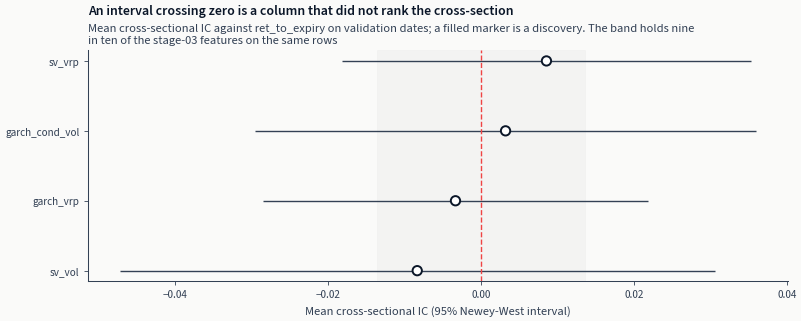

In [54]:
_ic_ordered = ic_summary.sort("ic_mean")
fig, ax = plt.subplots(figsize=(8, 3.2))
_y = np.arange(_ic_ordered.height)
_band = float(np.percentile(financial_abs_ic, IC_BAND_PERCENTILE))
ax.axvspan(-_band, _band, color=COLORS["silver_muted"], alpha=0.35, zorder=0)
ax.errorbar(
    _ic_ordered["ic_mean"].to_numpy(),
    _y,
    xerr=1.96 * _ic_ordered["hac_se"].to_numpy(),
    fmt="none",
    ecolor=COLORS["neutral"],
    elinewidth=1.0,
    capsize=3,
)
ax.scatter(
    _ic_ordered["ic_mean"].to_numpy(),
    _y,
    s=45,
    facecolor=[
        COLORS["blue"] if significant else "white"
        for significant in _ic_ordered["significant_fdr05"].to_list()
    ],
    # An unfilled marker outlined in the line colour, so a non-discovery still reads where it
    # overlaps the reference band rather than dissolving into it.
    edgecolor=COLORS["blue"],
    linewidths=1.4,
    zorder=3,
)
ax.axvline(0.0, color=COLORS["negative"], linestyle="--", linewidth=1)
ax.set_yticks(_y)
ax.set_yticklabels(_ic_ordered["feature"].to_list())
ax.set(xlabel="Mean cross-sectional IC (95% Newey-West interval)")
add_message_title(
    ax,
    "An interval crossing zero is a column that did not rank the cross-section",
    subtitle=(
        f"Mean cross-sectional IC against {label_col} on validation dates; a filled marker is a "
        "discovery. The band holds nine in ten of the stage-03 features on the same rows"
    ),
)
show_with_alt(
    fig,
    "Dot-and-interval chart of the mean cross-sectional information coefficient against "
    f"{label_col} for the four model-based columns, each with a 95 percent Newey-West "
    "interval, ordered sv_vrp, garch_cond_vol, garch_vrp and sv_vol from top to bottom. Every "
    "point sits within about 0.01 of zero and every interval crosses the dashed zero rule, so "
    "no marker is filled and none of the four is a discovery. A shaded band from about -0.013 "
    "to +0.013 marks where nine in ten of the stage-03 features fall on the same rows, and all "
    "four markers sit inside it, so these columns do not separate themselves from the features "
    "already written.",
)

The screen was run over **124,689** validation rows across **487** symbols, and no row had to be
dropped for resolving inside the holdout - the label buffer between each fold's training and
validation windows already leaves the last position settling on **2020-12-11**, three weeks clear.

**None of the four** columns clears the family threshold. The largest absolute mean IC among them
is the particle-filtered volatility's, at **0.010**, and its Newey-West standard error is
roughly twice that, so the estimate is smaller than the noise around it. All four fall inside the
band that holds nine in ten of the stage-03 features, which reaches **0.0128**; those features
have a median absolute mean IC of **0.0074** and a largest of **0.0349**. On this label, at this
horizon, single features of either kind rank the cross-section weakly, and these four are not the
exception.

The overlap correction is doing visible work: compare the two standard-error columns in the table
above. Ignoring it would divide every interval on the chart by that ratio, which is the difference
between reporting nothing and reporting a discovery for estimates this small.

What this establishes, and what it does not. Failing to reject a zero IC is not the same as
establishing one: the intervals are wide, and a column that ranks nothing on its own can still
carry information a model uses alongside others. Nor is a single-feature screen the last word on
incremental value - that needs a model scored with these columns and without them, and neither
this notebook nor the next one runs that ablation.

What the section does establish is where these four sit against the features the case study
already had, measured the same way on the same rows, and that they were produced without any
parameter seeing a date it is scored on.

**Next**: [`05_evaluation`](05_evaluation.ipynb) is the first notebook to read
`model_based.parquet`. It screens these four columns alongside the stage-03 features and decides
which of the whole set go forward.

## Key takeaways

1. **Estimate on one window, then run forward without re-estimating.** This is what separates a
   model-based feature from a rule-based one, and it is invisible in the values: two series that
   differ only in whether the parameters behind them read the future look identical. The fold
   contract in section B is what makes the difference checkable, and drawing it is cheaper than
   auditing the code that produced it.

2. **Derive everything the forward pass needs from the training window, including the parts a
   library computes for you.** Handing a fitted result back to a volatility library and asking it
   to filter a longer series will silently recompute initialization and clipping bounds from the
   longer series. Writing out the recursion is worth the twenty lines when the alternative is a
   leak with no symptom.

3. **A parameter that is a property of the market, not of the asset, is estimated once per
   window and shared.** That is what makes a sampler that costs minutes per symbol affordable at
   all, and it is a modelling decision to state rather than a shortcut to hide.

4. **Check that a sampler converged before using what it returned.** Draws from a chain that
   never mixed look exactly like draws from one that did. R-hat, effective sample size in bulk
   and tail, and the divergence count are the four that decide it here, and failing them stops
   the run rather than lowering the bar.

5. **Test a feature on the outcome that was actually traded, and correct the test for how the
   positions overlap.** Consecutive positions in this strategy share most of their holding
   period, so an uncorrected standard error is too small by a wide margin - and where several
   features are screened at once, the family correction, not the individual p-value, decides what
   counts as found.

### Known limitations

- The particle filter's output is an expectation over a finite population of candidate states, so
  it carries Monte Carlo noise of its own. A thousand candidates keeps that noise well below the
  day-to-day movement in the series, but it does not remove it, and a different seed gives a
  slightly different series.
- Both models read the underlying's returns only. Neither sees the option surface, so neither can
  respond to a change in what the market is charging until the underlying moves - which is
  exactly the lag the two premium columns are constructed to measure, and also a reason they are
  slow.
- The volatility columns are defined for every date in a pass, but the premium columns need a
  straddle quote on that date and are null where there was none. A model reading them has to
  handle that, and how it does so is a choice this stage does not make for it.